In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def load_and_preprocess_data():
    """Load CIFAR-10 dataset and preprocess it"""
    print("Loading CIFAR-10 dataset...")
    
    # Load the dataset
    (x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
    
    # Class names for CIFAR-10
    class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
                   'dog', 'frog', 'horse', 'ship', 'truck']
    
    print(f"Training data shape: {x_train.shape}")
    print(f"Training labels shape: {y_train.shape}")
    print(f"Test data shape: {x_test.shape}")
    print(f"Test labels shape: {y_test.shape}")
    print(f"Number of classes: {len(class_names)}")
    
    # Normalize pixel values to [0, 1]
    x_train = x_train.astype('float32') / 255.0
    x_test = x_test.astype('float32') / 255.0
    
    # Convert labels to categorical
    y_train_cat = keras.utils.to_categorical(y_train, 10)
    y_test_cat = keras.utils.to_categorical(y_test, 10)
    
    print("Data preprocessing completed!")
    
    return (x_train, y_train, y_train_cat), (x_test, y_test, y_test_cat), class_names

def visualize_sample_data(x_train, y_train, class_names, num_samples=10):
    """Visualize sample images from the dataset"""
    plt.figure(figsize=(15, 6))
    
    for i in range(num_samples):
        plt.subplot(2, 5, i + 1)
        plt.imshow(x_train[i])
        plt.title(f'Class: {class_names[y_train[i][0]]}')
        plt.axis('off')
    
    plt.suptitle('Sample CIFAR-10 Images')
    plt.tight_layout()
    plt.show()

def create_cnn_model(input_shape=(32, 32, 3), num_classes=10):
    """Create a custom CNN model for CIFAR-10 classification"""
    print("Creating Custom CNN Model...")
    
    model = keras.Sequential([
        # First Convolutional Block
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Second Convolutional Block
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Third Convolutional Block
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Fully Connected Layers
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    # Compile the model
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    print("Custom CNN Model created successfully!")
    model.summary()
    
    return model

def residual_block(x, filters, kernel_size=3, stride=1, conv_shortcut=False):
    """Create a residual block for ResNet"""
    shortcut = x
    
    # First convolution
    x = layers.Conv2D(filters, kernel_size, strides=stride, padding='same',
                     kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # Second convolution
    x = layers.Conv2D(filters, kernel_size, padding='same',
                     kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    
    # Shortcut connection
    if conv_shortcut:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same',
                               kernel_initializer='he_normal')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    elif stride > 1:
        shortcut = layers.MaxPooling2D(1, strides=stride)(shortcut)
        shortcut = layers.Conv2D(filters, 1, padding='same',
                                kernel_initializer='he_normal')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    
    # Add shortcut to main path
    x = layers.Add()([shortcut, x])
    x = layers.Activation('relu')(x)
    
    return x

def create_resnet18_model(input_shape=(32, 32, 3), num_classes=10):
    """Create ResNet-18 model from scratch"""
    print("Creating ResNet-18 Model...")
    
    inputs = layers.Input(shape=input_shape)
    
    # Initial convolution
    x = layers.Conv2D(64, 7, strides=2, padding='same',
                     kernel_initializer='he_normal')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(3, strides=2, padding='same')(x)
    
    # ResNet blocks
    # Block 1: 64 filters
    x = residual_block(x, 64, conv_shortcut=True)
    x = residual_block(x, 64)
    
    # Block 2: 128 filters
    x = residual_block(x, 128, stride=2, conv_shortcut=True)
    x = residual_block(x, 128)
    
    # Block 3: 256 filters
    x = residual_block(x, 256, stride=2, conv_shortcut=True)
    x = residual_block(x, 256)
    
    # Block 4: 512 filters
    x = residual_block(x, 512, stride=2, conv_shortcut=True)
    x = residual_block(x, 512)
    
    # Global average pooling and final dense layer
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax',
                          kernel_initializer='he_normal')(x)
    
    # Create model
    model = keras.Model(inputs, outputs, name='resnet18')
    
    # Compile the model
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    print("ResNet-18 Model created successfully!")
    model.summary()
    
    return model

def train_model(model, x_train, y_train_cat, x_test, y_test_cat, model_name, epochs=10):
    """Train the model with proper callbacks"""
    print(f"Training {model_name}...")
    
    # Callbacks
    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
    
    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
    
    # Data augmentation
    datagen = keras.preprocessing.image.ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        horizontal_flip=True,
        zoom_range=0.2
    )
    datagen.fit(x_train)
    
    # Train the model
    history = model.fit(
        datagen.flow(x_train, y_train_cat, batch_size=32),
        validation_data=(x_test, y_test_cat),
        epochs=epochs,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )
    
    print(f"{model_name} training completed!")
    
    return history

def plot_training_history(history, model_name):
    """Plot accuracy and loss curves"""
    plt.figure(figsize=(15, 5))
    
    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} - Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

def evaluate_model(model, x_test, y_test, y_test_cat, class_names, model_name):
    """Evaluate model performance and display results"""
    print(f"Evaluating {model_name}...")
    
    # Get predictions
    y_pred_prob = model.predict(x_test)
    y_pred = np.argmax(y_pred_prob, axis=1)
    
    # Calculate accuracy
    test_loss, test_accuracy = model.evaluate(x_test, y_test_cat, verbose=0)
    print(f"{model_name} Test Accuracy: {test_accuracy:.4f}")
    print(f"{model_name} Test Loss: {test_loss:.4f}")
    
    # Classification report
    print(f"\n{model_name} Classification Report:")
    print(classification_report(y_test.flatten(), y_pred, target_names=class_names))
    
    # Confusion matrix
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_test.flatten(), y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    return test_accuracy, test_loss

def compare_models(cnn_accuracy, cnn_loss, resnet_accuracy, resnet_loss):
    """Compare the performance of both models"""
    print("=" * 50)
    print("MODEL COMPARISON RESULTS")
    print("=" * 50)
    
    models = ['Custom CNN', 'ResNet-18']
    accuracies = [cnn_accuracy, resnet_accuracy]
    losses = [cnn_loss, resnet_loss]
    
    # Create comparison plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Accuracy comparison
    bars1 = ax1.bar(models, accuracies, color=['skyblue', 'lightcoral'])
    ax1.set_title('Model Accuracy Comparison')
    ax1.set_ylabel('Accuracy')
    ax1.set_ylim(0, 1)
    
    # Add value labels on bars
    for bar, acc in zip(bars1, accuracies):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{acc:.4f}', ha='center', va='bottom')
    
    # Loss comparison
    bars2 = ax2.bar(models, losses, color=['lightgreen', 'orange'])
    ax2.set_title('Model Loss Comparison')
    ax2.set_ylabel('Loss')
    
    # Add value labels on bars
    for bar, loss in zip(bars2, losses):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{loss:.4f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed comparison
    print(f"Custom CNN - Accuracy: {cnn_accuracy:.4f}, Loss: {cnn_loss:.4f}")
    print(f"ResNet-18 - Accuracy: {resnet_accuracy:.4f}, Loss: {resnet_loss:.4f}")
    
    if resnet_accuracy > cnn_accuracy:
        print(f"\n✅ ResNet-18 performs better with {(resnet_accuracy - cnn_accuracy) * 100:.2f}% higher accuracy")
    elif cnn_accuracy > resnet_accuracy:
        print(f"\n✅ Custom CNN performs better with {(cnn_accuracy - resnet_accuracy) * 100:.2f}% higher accuracy")
    else:
        print("\n🤝 Both models perform equally well!")

def visualize_predictions(model, x_test, y_test, class_names, model_name, num_samples=10):
    """Visualize model predictions on test samples"""
    # Get random samples
    indices = np.random.choice(len(x_test), num_samples, replace=False)
    
    # Get predictions
    predictions = model.predict(x_test[indices])
    predicted_classes = np.argmax(predictions, axis=1)
    
    plt.figure(figsize=(15, 8))
    
    for i, idx in enumerate(indices):
        plt.subplot(2, 5, i + 1)
        plt.imshow(x_test[idx])
        
        actual_class = class_names[y_test[idx][0]]
        predicted_class = class_names[predicted_classes[i]]
        confidence = np.max(predictions[i]) * 100
        
        # Color code: green for correct, red for incorrect
        color = 'green' if actual_class == predicted_class else 'red'
        
        plt.title(f'Actual: {actual_class}\nPredicted: {predicted_class}\nConf: {confidence:.1f}%', 
                 color=color, fontsize=8)
        plt.axis('off')
    
    plt.suptitle(f'{model_name} - Prediction Examples', fontsize=16)
    plt.tight_layout()
    plt.show()

Loading CIFAR-10 dataset...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)
Number of classes: 10
Data preprocessing completed!


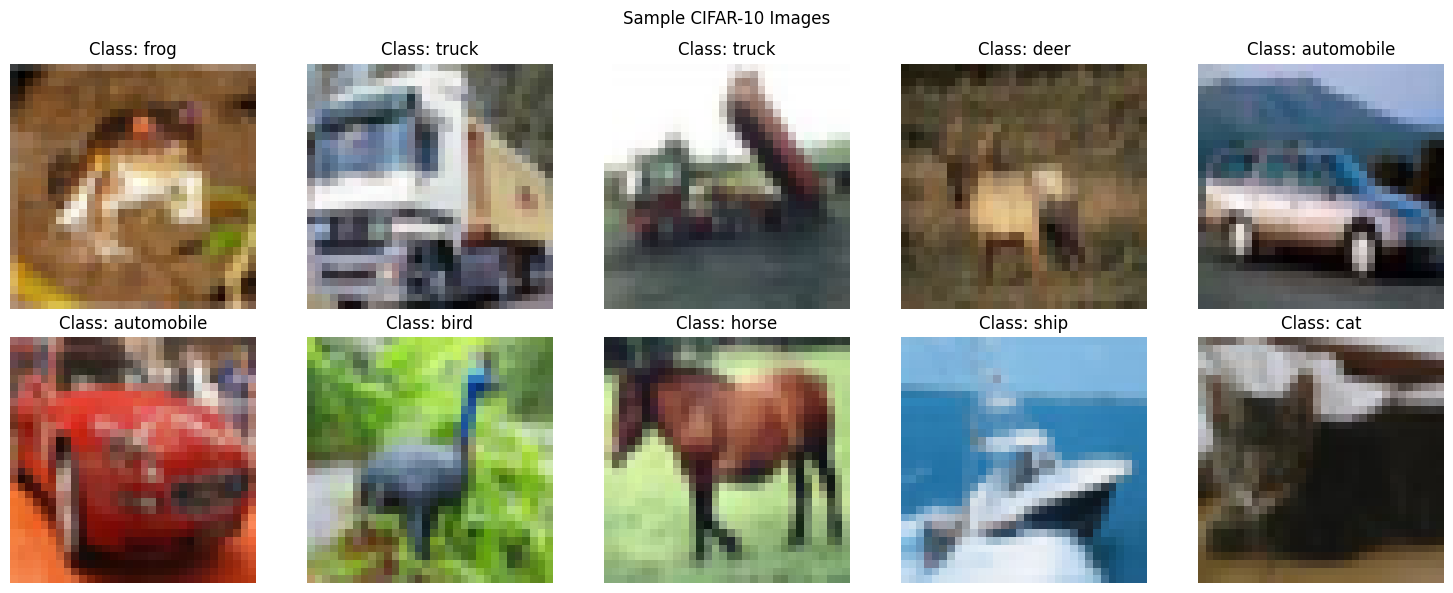

Creating Custom CNN Model...
Custom CNN Model created successfully!


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-09-20 18:11:30.036074: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,472,938 (5.62 MB)

 Trainable params: 1,471,466 (5.61 MB)

 Non-trainable params: 1,472 (5.75 KB)

Training Custom CNN...
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 204s 126ms/step - accuracy: 0.2584 - loss: 2.2465 - val_accuracy: 0.3850 - val_loss: 1.7713 - learning_rate: 0.0010
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 196s 125ms/step - accuracy: 0.4249 - loss: 1.5815 - val_accuracy: 0.4028 - val_loss: 1.8764 - learning_rate: 0.0010
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 196s 125ms/step - accuracy: 0.4889 - loss: 1.4174 - val_accuracy: 0.5468 - val_loss: 1.4005 - learning_rate: 0.0010
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 196s 125ms/step - accuracy: 0.5494 - loss: 1.2796 - val_accuracy: 0.6375 - val_loss: 1.0331 - learning_rate: 0.0010
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 195s 125ms/step - accuracy: 0.5836 - loss: 1.2018 - val_accuracy: 0.5591 - val_loss: 1.3654 - learning_rate: 0.0010
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 202s 124ms/step - accuracy: 0.6120 - loss: 1.1244 - val_accuracy: 0.6017 - val_loss: 1.2339 - learning_rate: 0.0010
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 195s 124ms/step - acc

In [ ]:
train_data, test_data, class_names = load_and_preprocess_data()
visualize_sample_data(train_data[0], train_data[1], class_names)
cnn_model = create_cnn_model()
cnn_history = train_model(cnn_model, train_data[0], train_data[2], test_data[0], test_data[2], 'Custom CNN')
plot_training_history(cnn_history, 'Custom CNN')
cnn_acc, cnn_loss = evaluate_model(cnn_model, test_data[0], test_data[1], test_data[2], class_names, 'Custom CNN')
resnet_model = create_resnet18_model()
resnet_history = train_model(resnet_model, train_data[0], train_data[2], test_data[0], test_data[2], 'ResNet-18')
plot_training_history(resnet_history, 'ResNet-18')
resnet_acc, resnet_loss = evaluate_model(resnet_model, test_data[0], test_data[1], test_data[2], class_names, 'ResNet-18')
compare_models(cnn_acc, cnn_loss, resnet_acc, resnet_loss)
visualize_predictions(cnn_model, test_data[0], test_data[1], class_names, 'Custom CNN')
visualize_predictions(resnet_model, test_data[0], test_data[1], class_names, 'ResNet-18')